# MVP — Machine Learning & Analytics
## Previsão de Taxas do Tesouro Direto

**Disciplina:** Machine Learning & Analytics  
**Especialização em Ciência de Dados e Big Data — PUC-Rio**  
**Autor:** Marcio Goulart Mocellin  
**Matrícula:** 4052026000399  
**Data:** Julho de 2026  
**Dataset:** Taxas dos Títulos Ofertados pelo Tesouro Direto  
**Fonte:** Tesouro Nacional — dados abertos ([link](https://www.tesourotransparente.gov.br/ckan/dataset/df56aa42-484a-4a59-8184-7676580c81e3))  

---

## 1. Apresentação do Problema

### 1.1 Descrição do Problema

O Tesouro Direto é o programa de investimento em títulos públicos federais do governo brasileiro, voltado para pessoas físicas. Desde o seu lançamento em 2002, o programa disponibiliza diariamente as taxas de negociação de seus títulos — informação fundamental para investidores, gestores de portfólio e analistas econômicos.

A taxa de juros associada a cada título reflete o rendimento que o investidor receberá ao final do período. Essa taxa varia diariamente conforme as condições do mercado financeiro, decisões de política monetária e expectativas econômicas.

**Fonte do conjunto de dados:**
- CSV: https://www.tesourotransparente.gov.br/ckan/dataset/df56aa42-484a-4a59-8184-7676580c81e3/resource/796d2059-14e9-44e3-80c9-2d9e30b405c1/download/precotaxatesourodireto.csv
- Metadados: https://www.tesourotransparente.gov.br/ckan/dataset/df56aa42-484a-4a59-8184-7676580c81e3/resource/1a8eb2e3-4902-4a38-a1eb-6410f23d90de/download/taxa.pdf

### 1.2 Objetivo do Modelo

O objetivo deste MVP é construir e comparar modelos de Machine Learning capazes de **prever a taxa de venda da manhã do Tesouro Prefixado** para o dia seguinte (horizonte de 1 dia). A variável-alvo é `taxa_venda` (Taxa de Venda — Manhã), expressa em percentual ao ano.

### 1.3 Tipo de Tarefa de Machine Learning

Este é um problema de **previsão de séries temporais** tratado como **regressão supervisionada**. A abordagem utilizada é a de **janela deslizante (sliding window)**: transformamos a série temporal em um problema de regressão convencional criando features a partir de valores históricos (lags) e estatísticas de janela móvel.

### 1.4 Por Que Machine Learning Para Este Problema?

As taxas de juros são influenciadas por múltiplos fatores com relações não-lineares e complexas:
- **Inércia temporal**: as taxas exibem autocorrelação significativa — valores passados influenciam valores futuros.
- **Sazonalidade e tendências**: podem existir padrões mensais, trimestrais e anuais associados ao calendário econômico.
- **Volatilidade variável**: períodos de alta instabilidade (ex: crises) geram padrões diferentes dos períodos de estabilidade.

Modelos de ML, especialmente métodos ensemble como Random Forest e Gradient Boosting, são capazes de capturar relações não-lineares entre features de lag e a variável-alvo, superando abordagens lineares simples.

### 1.5 Premissas, Hipóteses e Restrições

- **Premissa 1**: O comportamento futuro das taxas guarda relação com o comportamento recente (autocorrelação).
- **Premissa 2**: Padrões calendários (mês, trimestre) podem capturar sazonalidade relacionada a reuniões do COPOM.
- **Hipótese**: Modelos com maior capacidade de capturar não-linearidades (Random Forest, Gradient Boosting) superarão modelos lineares (Linear Regression, Ridge).
- **Restrição 1**: O MVP utiliza apenas features derivadas da própria série de taxas (abordagem univariada com features de lag). Não são utilizadas variáveis externas como IPCA, câmbio ou expectativas de mercado.
- **Restrição 2**: O horizonte de previsão é de **1 dia à frente** (*one-step ahead forecast*).
- **Restrição 3**: Para garantir uma série temporal limpa e contínua, o MVP se concentra em **um único título** (Tesouro Prefixado).

---
## 2. Configuração do Ambiente

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import pacf, acf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
import warnings
import time

warnings.filterwarnings('ignore')

# Paleta consistente para todas as visualizações
COLOR_PRIMARY = '#1f4e79'     # Azul principal
COLOR_SECONDARY = '#e07a1f'   # Laranja de contraste
COLOR_ACCENT = '#2a9d8f'      # Verde para destaque
COLOR_ALERT = '#c1121f'       # Vermelho para corte/limites
COLOR_NEUTRAL = '#6c757d'     # Cinza para baseline
COLOR_DARK = '#2f2f2f'

sns.set_theme(style='whitegrid', palette=[COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT])
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Semente aleatória para reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import sklearn
print('Ambiente configurado com sucesso!')
print(f'  pandas      : {pd.__version__}')
print(f'  numpy       : {np.__version__}')
print(f'  scikit-learn: {sklearn.__version__}')

Ambiente configurado com sucesso!
  pandas      : 2.2.2
  numpy       : 2.0.2
  scikit-learn: 1.6.1


---
## 3. Carregamento dos Dados

O dataset é carregado diretamente da URL pública disponibilizada pelo Tesouro Nacional. O arquivo está no formato CSV com separador `;`, separador decimal `,` e codificação `latin-1` — padrão comum em bases de dados governamentais brasileiras.

In [39]:
URL = (
    'https://www.tesourotransparente.gov.br/ckan/dataset/'
    'df56aa42-484a-4a59-8184-7676580c81e3/resource/'
    '796d2059-14e9-44e3-80c9-2d9e30b405c1/download/precotaxatesourodireto.csv'
)

print('Carregando dados do Tesouro Direto...')
t0 = time.time()

df_raw = pd.read_csv(
    URL,
    sep=';',
    decimal=',',
    encoding='latin-1',
    thousands=None,
    parse_dates = ["Data Vencimento", "Data Base"],
    dayfirst = True,
)

# Remover espaços extras dos nomes de colunas
df_raw.columns = df_raw.columns.str.strip()

elapsed = time.time() - t0
print(f'Dados carregados em {elapsed:.1f}s')
print(f'Shape: {df_raw.shape[0]:,} registros x {df_raw.shape[1]} atributos')
print(f'Colunas: {list(df_raw.columns)}')

Carregando dados do Tesouro Direto...
Dados carregados em 24.1s
Shape: 172,958 registros x 8 atributos
Colunas: ['Tipo Titulo', 'Data Vencimento', 'Data Base', 'Taxa Compra Manha', 'Taxa Venda Manha', 'PU Compra Manha', 'PU Venda Manha', 'PU Base Manha']


---
## 4. Apresentação dos Dados

### 4.1 Primeiras Linhas

In [40]:
df_raw.head(10)

,Tipo Titulo,Data Vencimento,Data Base,Taxa Compra Manha,Taxa Venda Manha,PU Compra Manha,PU Venda Manha,PU Base Manha
0,Tesouro IPCA+ com Juros Semestrais,2008-08-15,2007-06-11,7.3600,7.3800,1655.6500,1655.3000,1654.6900
1,Tesouro IPCA+ com Juros Semestrais,2012-08-15,2007-06-11,6.3600,6.4200,1654.8800,1650.7400,1650.1800
2,Tesouro IPCA+ com Juros Semestrais,2045-05-15,2007-06-11,5.9200,6.0200,1679.1800,1654.8500,1654.3200
3,Tesouro IPCA+ com Juros Semestrais,2035-05-15,2007-06-11,5.9500,6.0500,1670.2600,1648.4800,1647.9500
4,Tesouro IPCA+ com Juros Semestrais,2024-08-15,2007-06-11,5.9900,6.0700,1684.0800,1670.4400,1669.9000
5,Tesouro IPCA+ com Juros Semestrais,2017-05-15,2007-06-11,6.1100,6.1700,1644.2700,1637.2400,1636.7000
6,Tesouro IPCA+ com Juros Semestrais,2015-05-15,2007-06-11,6.2100,6.2700,1635.7700,1629.8800,1629.3400
7,Tesouro IPCA+,2024-08-15,2007-06-11,5.9000,5.9800,617.6100,609.6700,609.4800
8,Tesouro IPCA+,2015-05-15,2007-06-11,6.1500,6.2100,1028.0500,1023.4600,1023.1300
9,Tesouro IGPM+ com Juros Semestrais,2017-07-01,2007-06-11,6.1100,6.1900,1953.5800,1942.5700,1942.0400


### 4.2 Informações Gerais

In [41]:
print('=== Informações Gerais do Dataset ===')
print(f'  Registros   : {len(df_raw):,}')
print(f'  Atributos   : {df_raw.shape[1]}')
print(f'  Periodo     : {df_raw["Data Base"].min().date()} a {df_raw["Data Base"].max().date()}')
print(f'  Anos cobertos: {df_raw["Data Base"].dt.year.nunique()}')
print()

print('=== Tipos de Títulos Disponíveis ===')
titulos = df_raw['Tipo Titulo'].value_counts()
print(titulos.to_string())
print()

print('=== Tipos de Dados ===')
print(df_raw.dtypes)

=== Informações Gerais do Dataset ===
  Registros   : 172,958
  Atributos   : 8
  Periodo     : 2004-12-31 a 2026-06-29
  Anos cobertos: 23

=== Tipos de Títulos Disponíveis ===
Tipo Titulo
Tesouro IPCA+ com Juros Semestrais        43409
Tesouro Prefixado                         27835
Tesouro Prefixado com Juros Semestrais    26917
Tesouro Selic                             21161
Tesouro IPCA+                             18452
Tesouro IGPM+ com Juros Semestrais        15737
Tesouro Educa+                            12647
Tesouro Renda+ Aposentadoria Extra         6800

=== Tipos de Dados ===
Tipo Titulo                  object
Data Vencimento      datetime64[ns]
Data Base            datetime64[ns]
Taxa Compra Manha           float64
Taxa Venda Manha            float64
PU Compra Manha             float64
PU Venda Manha              float64
PU Base Manha               float64
dtype: object


### 4.3 Descrição dos Atributos

| Atributo | Tipo | Descrição |
|---|---|---|
| **Tipo Titulo** | Categórico | Nome do título |
| **Data Vencimento** | Data | Data de vencimento do título |
| **Data Base** | Data | Data da cotação (índice temporal) |
| **Taxa Compra Manha** | Numérico (% a.a.) | Taxa de compra divulgada pela manhã |
| **Taxa Venda Manha** | Numérico (% a.a.) | Taxa de venda divulgada pela manhã (**variável-alvo**) |
| **PU Compra Manha** | Numérico (R$) | Preço unitário de compra pela manhã |
| **PU Venda Manha** | Numérico (R$) | Preço unitário de venda pela manhã |
| **PU Base Manha** | Numérico (R$) | Preço unitário base pela manhã |

**Variável-alvo**: `Taxa Venda Manha` — taxa de venda divulgada pela manhã, expressa em % ao ano.  
Esta é a taxa mais relevante do ponto de vista do investidor, pois representa o custo de aquisição do título.

**Limitações conhecidas**:
- Diferentes títulos têm diferentes períodos de disponibilidade.
- O MVP não usa variáveis macroeconômicas externas, limitando o poder preditivo.

### 4.4 Seleção do Título para Análise

Para garantir uma série temporal contínua e coerente, o MVP se concentra em **um único título Tesouro Prefixado**, pois como visto no trabalho anterior (https://github.com/marciomocellin/analise-tesouro-direto) apresentou uma boa simetria em sua distribuição de taxas.

In [42]:
# Filtrar apenas títulos Tesouro Prefixado
mask_prefixado = df_raw['Tipo Titulo'].str.contains('Tesouro Prefixado', na=False)
df_prefixado_all = df_raw[mask_prefixado].copy()

# Identificar o vencimento com mais observações
contagem_venc = df_prefixado_all.groupby('Data Vencimento').size().sort_values(ascending=False)
print('Quantidade de observações por vencimento (Tesouro Prefixado):')
print(contagem_venc.head(10).to_string())

melhor_venc = contagem_venc.index[0]
print(f'\nTítulo selecionado: Tesouro Prefixado com vencimento em {melhor_venc.date()}')
print(f'Total de observações: {contagem_venc.iloc[0]:,}')

Quantidade de observações por vencimento (Tesouro Prefixado):
Data Vencimento
2025-01-01    4441
2023-01-01    4360
2021-01-01    4176
2017-01-01    3489
2027-01-01    3191
2029-01-01    3173
2014-01-01    2558
2012-01-01    2241
2031-01-01    2187
2013-01-01    2116

Título selecionado: Tesouro Prefixado com vencimento em 2025-01-01
Total de observações: 4,441


In [43]:
# Filtrar e organizar o dataset do título selecionado
df_sel = df_prefixado_all[df_prefixado_all['Data Vencimento'] == melhor_venc].copy()
df_sel = df_sel.sort_values('Data Base').reset_index(drop=True)

# Selecionar colunas relevantes
colunas_manter = ['Data Base', 'Taxa Compra Manha', 'Taxa Venda Manha',
                  'PU Compra Manha', 'PU Venda Manha']
colunas_existentes = [c for c in colunas_manter if c in df_sel.columns]
df_sel = df_sel[colunas_existentes].copy()

# Renomear colunas para uso mais fácil
renomear = {
    'Data Base': 'data',
    'Taxa Compra Manha': 'taxa_compra',
    'Taxa Venda Manha': 'taxa_venda',
    'PU Compra Manha': 'pu_compra',
    'PU Venda Manha': 'pu_venda',
}
df_sel = df_sel.rename(columns={k: v for k, v in renomear.items() if k in df_sel.columns})
df_sel = df_sel.set_index('data')

print(f'Shape do dataset filtrado: {df_sel.shape}')
print(f'Período: {df_sel.index.min().date()} a {df_sel.index.max().date()}')
print()
print('Estatísticas descritivas da variável-alvo (Taxa Venda Manha):')
print(df_sel['taxa_venda'].describe())

Shape do dataset filtrado: (4441, 4)
Período: 2014-01-27 a 2024-12-30

Estatísticas descritivas da variável-alvo (Taxa Venda Manha):
count   4441.0000
mean      10.2921
std        2.4048
min        5.1300
25%        8.6500
50%       10.6200
75%       12.0500
max       16.7600
Name: taxa_venda, dtype: float64


---
## 5. Análise Exploratória Inicial

### 5.1 Visualização da Série Temporal

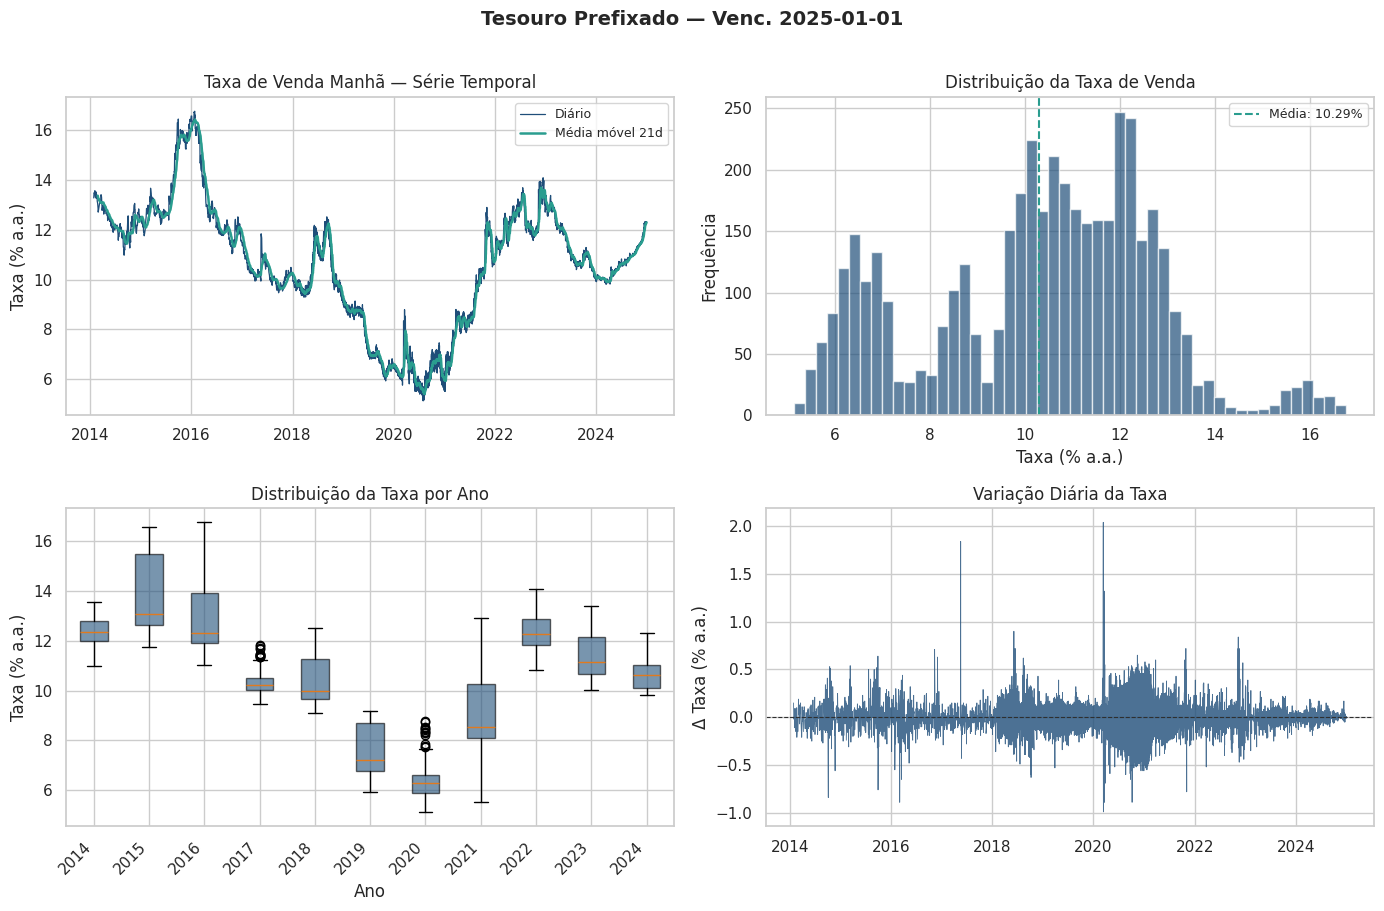

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# --- Série temporal principal ---
ax = axes[0, 0]
ax.plot(df_sel.index, df_sel['taxa_venda'], linewidth=0.9, color=COLOR_PRIMARY, label='Diário')
roll21 = df_sel['taxa_venda'].rolling(21).mean()
ax.plot(df_sel.index, roll21, linewidth=1.8, color=COLOR_ACCENT, label='Média móvel 21d')
ax.set_title('Taxa de Venda Manhã — Série Temporal', fontsize=12)
ax.set_ylabel('Taxa (% a.a.)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# --- Distribuição ---
ax = axes[0, 1]
ax.hist(df_sel['taxa_venda'].dropna(), bins=50, color=COLOR_PRIMARY, alpha=0.7, edgecolor='white')
ax.axvline(df_sel['taxa_venda'].mean(), color=COLOR_ACCENT, linestyle='--',
           linewidth=1.5, label=f'Média: {df_sel["taxa_venda"].mean():.2f}%')
ax.set_title('Distribuição da Taxa de Venda', fontsize=12)
ax.set_xlabel('Taxa (% a.a.)')
ax.set_ylabel('Frequência')
ax.legend(fontsize=9)

# --- Boxplot por ano ---
ax = axes[1, 0]
df_ano = df_sel[['taxa_venda']].copy()
df_ano['ano'] = df_sel.index.year
grupos = [df_ano.loc[df_ano['ano'] == a, 'taxa_venda'].dropna().values
          for a in sorted(df_ano['ano'].unique())]
anos = sorted(df_ano['ano'].unique())
ax.boxplot(grupos, labels=anos, patch_artist=True,
           boxprops=dict(facecolor=COLOR_PRIMARY, alpha=0.6))
ax.set_title('Distribuição da Taxa por Ano', fontsize=12)
ax.set_xlabel('Ano')
ax.set_ylabel('Taxa (% a.a.)')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# --- Variação diária ---
ax = axes[1, 1]
variacao = df_sel['taxa_venda'].diff()
ax.plot(df_sel.index, variacao, linewidth=0.6, color=COLOR_PRIMARY, alpha=0.8)
ax.axhline(0, color=COLOR_DARK, linewidth=0.8, linestyle='--')
ax.set_title('Variação Diária da Taxa', fontsize=12)
ax.set_ylabel('Δ Taxa (% a.a.)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


plt.suptitle(
    f'Tesouro Prefixado — Venc. {melhor_venc.date()}',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

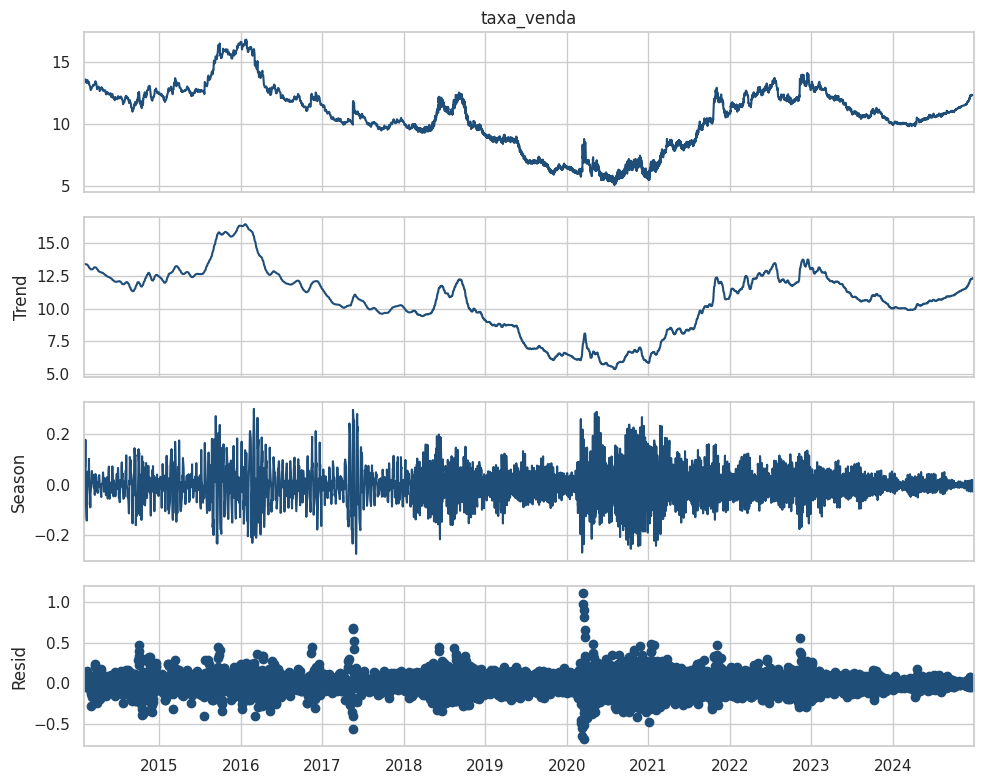

In [45]:
# --- decompor uma série temporal ---

stl = STL(serie, period=12)
resultado_stl = stl.fit()
resultado_stl.plot()
plt.show()

Aparentemente, a série temporal da taxa de venda do Tesouro Prefixado se apresentou **estacionária** ao longo do período analisado, não foi possível identificar padrões nas **flutuações sazonais** no período de 12 meses.

### 5.2 Estatísticas Descritivas

In [46]:
print('=== Estatísticas Descritivas ===')
desc = df_sel.describe()
print(desc.to_string())
print()

print('=== Valores Ausentes ===')
ausentes = df_sel.isnull().sum()
pct_ausentes = (ausentes / len(df_sel) * 100).round(2)
df_ausentes = pd.DataFrame({'Nulos': ausentes, '% Nulos': pct_ausentes})
print(df_ausentes.to_string())

=== Estatísticas Descritivas ===
       taxa_compra  taxa_venda  pu_compra  pu_venda
count    4441.0000   4441.0000  4441.0000 4441.0000
mean       10.1817     10.2921   907.4052  904.2074
std         2.4162      2.4048   165.8270  165.5444
min         5.0100      5.1300   474.2600  470.9400
25%         8.5300      8.6500   770.7700  767.9500
50%        10.5000     10.6200   938.5800  935.9100
75%        11.9500     12.0500  1024.3100 1021.2800
max        16.7000     16.7600  1221.7200 1216.5800

=== Valores Ausentes ===
             Nulos  % Nulos
taxa_compra      0   0.0000
taxa_venda       0   0.0000
pu_compra        0   0.0000
pu_venda         0   0.0000


### 5.3 Análise de Autocorrelação e Autocorrelação Parcial


A Função de Autocorrelação (ACF – *Autocorrelation Function*) mede a correlação entre uma série temporal e suas próprias versões defasadas ao longo do tempo. Valores elevados de autocorrelação indicam que observações passadas contêm informações relevantes para prever valores futuros, justificando a utilização de variáveis defasadas (*lag features*) na modelagem.

Já a Função de Autocorrelação Parcial (PACF – *Partial Autocorrelation Function*) mede a correlação entre a série e uma determinada defasagem, removendo o efeito das defasagens intermediárias. Dessa forma, a PACF permite identificar a contribuição direta de cada atraso para a explicação da série, auxiliando na seleção das defasagens mais relevantes.

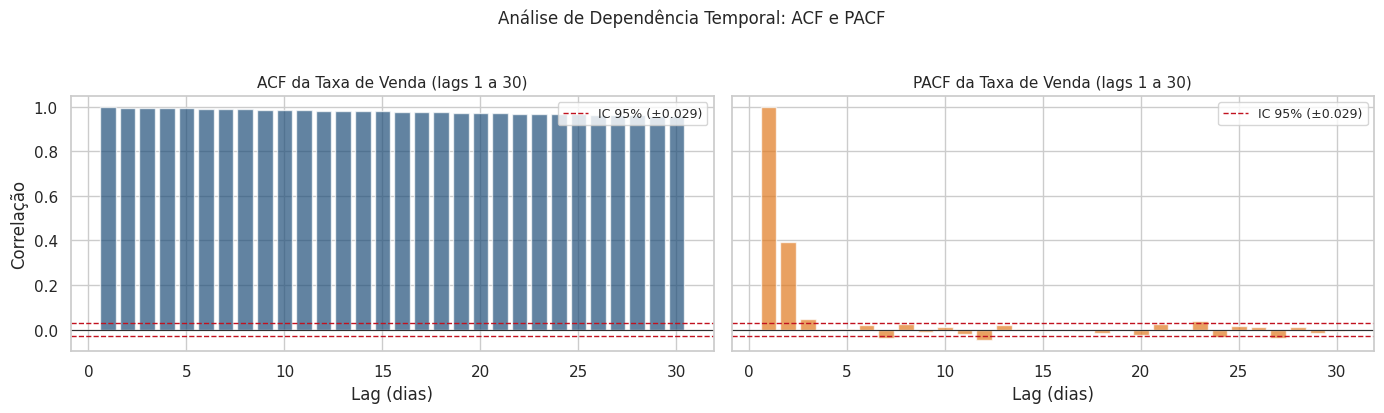

Autocorrelações (ACF) para lags selecionados:
  Lag  1: 0.9970
  Lag  2: 0.9966
  Lag  3: 0.9954
  Lag  5: 0.9934
  Lag 10: 0.9885
  Lag 21: 0.9761

Autocorrelações parciais (PACF) para lags selecionados:
  Lag  1: 0.9967
  Lag  2: 0.3936
  Lag  3: 0.0491
  Lag  5: 0.0032
  Lag 10: 0.0131
  Lag 21: 0.0274


In [47]:
serie = df_sel['taxa_venda'].dropna()

# Calcular autocorrelações para diferentes lags
max_lag = 30
acf_values = acf(serie, nlags=max_lag)[1:]
pacf_values = pacf(serie, nlags=max_lag, method='ywm')[1:]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

# ACF
ax = axes[0]
ax.bar(range(1, max_lag + 1), acf_values, color=COLOR_PRIMARY, alpha=0.7)
ax.axhline(0, color=COLOR_DARK, linewidth=0.8)
ci = 1.96 / np.sqrt(len(serie))
ax.axhline(ci, color=COLOR_ALERT, linestyle='--', linewidth=1, label=f'IC 95% (±{ci:.3f})')
ax.axhline(-ci, color=COLOR_ALERT, linestyle='--', linewidth=1)
ax.set_title('ACF da Taxa de Venda (lags 1 a 30)', fontsize=11)
ax.set_xlabel('Lag (dias)')
ax.set_ylabel('Correlação')
ax.legend(fontsize=9)

# PACF
ax = axes[1]
ax.bar(range(1, max_lag + 1), pacf_values, color=COLOR_SECONDARY, alpha=0.7)
ax.axhline(0, color=COLOR_DARK, linewidth=0.8)
ax.axhline(ci, color=COLOR_ALERT, linestyle='--', linewidth=1, label=f'IC 95% (±{ci:.3f})')
ax.axhline(-ci, color=COLOR_ALERT, linestyle='--', linewidth=1)
ax.set_title('PACF da Taxa de Venda (lags 1 a 30)', fontsize=11)
ax.set_xlabel('Lag (dias)')
ax.legend(fontsize=9)

plt.suptitle('Análise de Dependência Temporal: ACF e PACF', fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

print('Autocorrelações (ACF) para lags selecionados:')
for lag in [1, 2, 3, 5, 10, 21]:
    print(f'  Lag {lag:2d}: {serie.autocorr(lag=lag):.4f}')

print('\nAutocorrelações parciais (PACF) para lags selecionados:')
for lag in [1, 2, 3, 5, 10, 21]:
    print(f'  Lag {lag:2d}: {pacf_values[lag-1]:.4f}')

A análise da Função de Autocorrelação (ACF) revelou valores extremamente elevados em todas as defasagens avaliadas, variando de 0,997 no lag 1 a 0,976 no lag 21. Esse comportamento evidencia uma forte persistência temporal, indicando que observações passadas possuem elevada capacidade explicativa sobre os valores futuros da série.

Por outro lado, a Função de Autocorrelação Parcial (PACF) mostrou um pico dominante no lag 1 (0,997), seguido por uma contribuição ainda relevante no lag 2 (0,394). A partir do lag 3, os coeficientes tornam-se bastante reduzidos, sugerindo que a maior parte da dependência temporal é explicada pelas duas primeiras defasagens.

Esses resultados indicam que a inclusão de variáveis defasadas, especialmente dos lags 1 e 2, tende a capturar grande parte da estrutura temporal da série, enquanto defasagens mais longas agregam pouca informação adicional após o controle dos efeitos dos primeiros atrasos.

---
## 6. Preparação dos Dados

### 6.1 Tratamento de Valores Ausentes

Gaps na série podem ocorrer por suspensões temporárias do título. Optou-se por **preencher os valores ausentes com o método forward-fill** (último valor conhecido), que é uma abordagem coerente para séries de preços financeiros — o valor do dia anterior representa a melhor estimativa disponível até o próximo pregão.

In [70]:
df_sel

,taxa_compra,taxa_venda,pu_compra,pu_venda
data,,,,
2014-01-27,13.2200,13.2800,832.9400,830.1000
2014-01-28,13.3700,13.4300,826.2800,823.4800
2014-01-29,13.4300,13.4900,823.8900,821.1000
2014-01-30,13.4300,13.4900,824.3000,821.5100
2014-01-31,13.4100,13.4700,825.6400,822.8500
...,...,...,...,...
2024-12-26,12.2000,12.3200,998.6300,998.1500
2024-12-27,12.2000,12.3200,999.0800,998.6100
2024-12-27,12.2000,12.3200,1047.8500,1047.3500


In [48]:
# Verificar ausentes antes do tratamento
print(f'Valores ausentes em taxa_venda antes: {df_sel["taxa_venda"].isnull().sum()}')

# Forward-fill para manter continuidade temporal
df_ts = df_sel.copy()
df_ts['taxa_venda'] = df_ts['taxa_venda'].ffill()

print(f'Valores ausentes em taxa_venda depois: {df_ts["taxa_venda"].isnull().sum()}')
print(f'\nSérie final: {len(df_ts)} observações diárias')

Valores ausentes em taxa_venda antes: 0
Valores ausentes em taxa_venda depois: 0

Série final: 4441 observações diárias


### 6.2 Engenharia de Features

Transformamos a série temporal em um problema de regressão supervisionada criando as seguintes features:

| Feature | Descrição | Justificativa |
|---|---|---|
| `lag_1`, `lag_2`, `lag_3`, `lag_5`, `lag_10`, `lag_21` | Valores defasados (1, 2, 3, 5, 10, 21 dias) | Captura autocorrelação de curto prazo |
| `roll_mean_5`, `roll_mean_21` | Média móvel de 5 e 21 dias | Captura tendência recente (semana e mês) |
| `roll_std_5`, `roll_std_21` | Desvio padrão móvel de 5 e 21 dias | Captura volatilidade recente |
| `diff_1`, `diff_5` | Variação em 1 e 5 dias | Captura o momentum da taxa |
| `month`, `quarter` | Mês e trimestre | Captura sazonalidade (ex: reuniões COPOM) |
| `day_of_week` | Dia da semana | Captura efeitos de dia da semana |
| `year` | Ano | Permite ao modelo capturar tendências de longo prazo |
| `time_idx` | Índice de tempo (0, 1, 2, ...) | Feature de tendência linear |

**Importante sobre vazamento de dados**: as features de lag usam `.shift(lag)` e as features de rolling/diff usam `.shift(1)` antes do cálculo, garantindo que apenas informações anteriores ao dia previsto sejam usadas. Isso evita *data leakage*.

In [49]:
def criar_features(serie, lags=None, janelas=None):
    """
    Cria features de lag, rolling e calendário para previsão de série temporal.

    Parameters
    ----------
    serie : pd.Series
        Série temporal indexada por data.
    lags : list of int
        Lags a serem criados (ex: [1, 2, 3, 5, 10, 21]).
    janelas : list of int
        Tamanhos de janela para rolling mean e std.

    Returns
    -------
    pd.DataFrame com variável-alvo e todas as features.
    """
    if lags is None:
        lags = [1, 2, 3, 5, 10, 21]
    if janelas is None:
        janelas = [5, 21]

    df_f = pd.DataFrame({'taxa_venda': serie})

    # Features de lag
    for lag in lags:
        df_f[f'lag_{lag}'] = serie.shift(lag)

    # Estatísticas de janela móvel (shift(1) para evitar vazamento)
    for w in janelas:
        df_f[f'roll_mean_{w}'] = serie.shift(1).rolling(w).mean()
        df_f[f'roll_std_{w}'] = serie.shift(1).rolling(w).std()

    # Variações (momentum)
    df_f['diff_1'] = serie.diff(1).shift(1)
    df_f['diff_5'] = serie.diff(5).shift(1)

    # Features de calendário
    df_f['year'] = serie.index.year
    df_f['month'] = serie.index.month
    df_f['quarter'] = serie.index.quarter
    df_f['day_of_week'] = serie.index.dayofweek
    df_f['day_of_year'] = serie.index.dayofyear

    # Feature de tendência linear
    df_f['time_idx'] = np.arange(len(serie))

    # Remover linhas com NaN geradas pelos lags
    df_f = df_f.dropna()
    return df_f


df_features = criar_features(df_ts['taxa_venda'])

print(f'Shape após engenharia de features: {df_features.shape}')
print(f'Período: {df_features.index.min().date()} a {df_features.index.max().date()}')
print(f'\nFeatures criadas ({len(df_features.columns) - 1}):')
print([c for c in df_features.columns if c != 'taxa_venda'])

Shape após engenharia de features: (4420, 19)
Período: 2014-02-25 a 2024-12-30

Features criadas (18):
['lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_10', 'lag_21', 'roll_mean_5', 'roll_std_5', 'roll_mean_21', 'roll_std_21', 'diff_1', 'diff_5', 'year', 'month', 'quarter', 'day_of_week', 'day_of_year', 'time_idx']


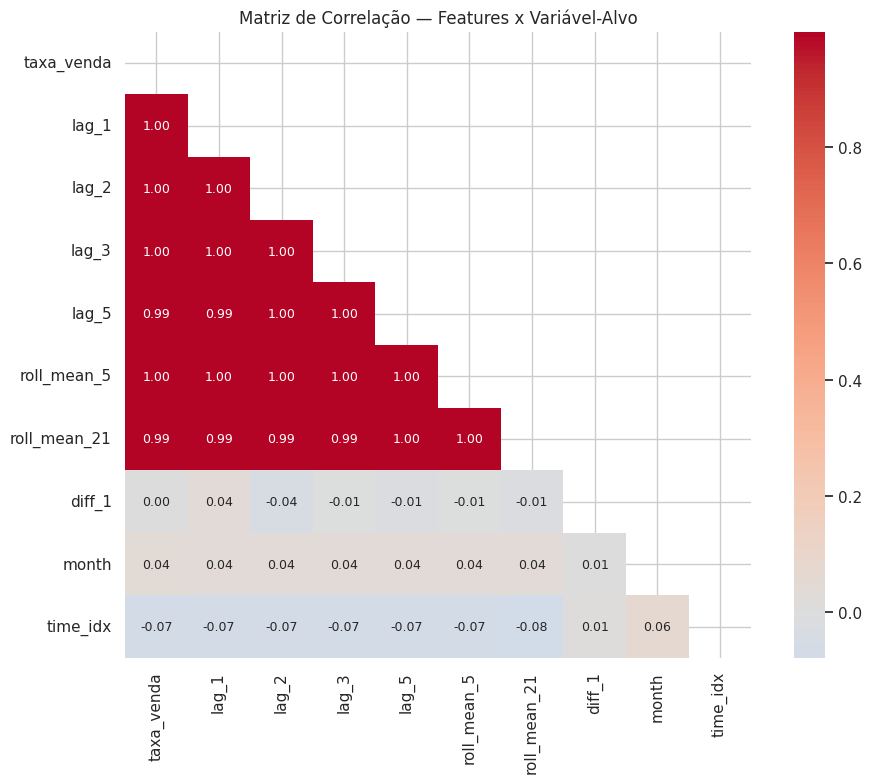

In [50]:
# Matriz de correlação entre as principais features e a variável-alvo
colunas_corr = ['taxa_venda', 'lag_1', 'lag_2', 'lag_3', 'lag_5',
                'roll_mean_5', 'roll_mean_21', 'diff_1', 'month', 'time_idx']
colunas_corr = [c for c in colunas_corr if c in df_features.columns]

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_features[colunas_corr].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, ax=ax, annot_kws={'size': 9}
)
ax.set_title('Matriz de Correlação — Features x Variável-Alvo', fontsize=12)
plt.tight_layout()
plt.show()

---
## 7. Divisão dos Dados (Treino e Teste)

Para séries temporais, a divisão **deve respeitar a ordem temporal** dos dados. Não é adequado usar divisão aleatória, pois isso geraria vazamento de informação futura para o treinamento.

A estratégia adotada é:
- **80% dos dados** (período mais antigo) → **Conjunto de Treino**
- **20% dos dados** (período mais recente) → **Conjunto de Teste**

Esta abordagem simula um cenário realista: o modelo é treinado com o histórico disponível e avaliado em dados que ele "ainda não viu".

=== Divisão Treino / Teste ===
  Data de corte  : 2023-03-24
  Treino         : 3,536 amostras (80.0%) [2014-02-25 → 2023-03-23]
  Teste          : 884 amostras (20.0%) [2023-03-24 → 2024-12-30]


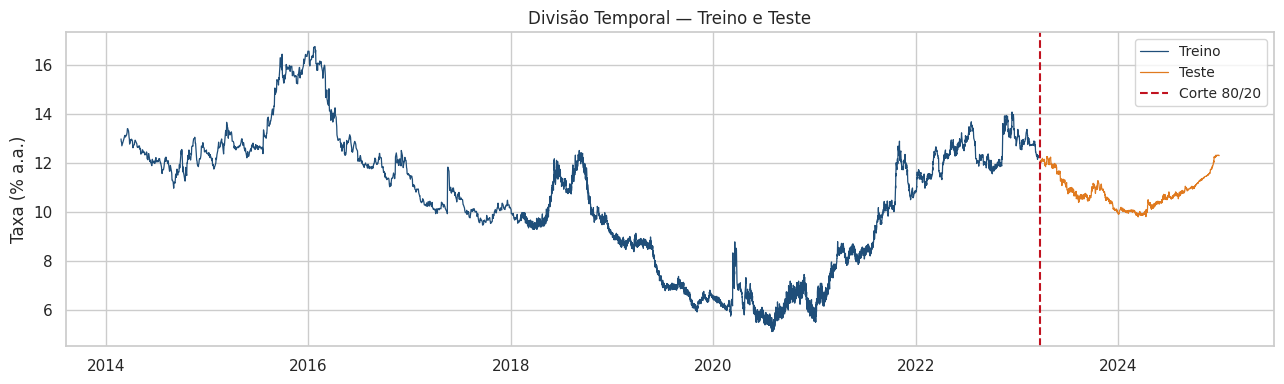

In [51]:
TARGET = 'taxa_venda'
FEATURES = [c for c in df_features.columns if c != TARGET]

# Divisão temporal 80/20
n_total = len(df_features)
n_treino = int(n_total * 0.80)
data_corte = df_features.index[n_treino]

X = df_features[FEATURES]
y = df_features[TARGET]

X_treino = X.iloc[:n_treino]
X_teste = X.iloc[n_treino:]
y_treino = y.iloc[:n_treino]
y_teste = y.iloc[n_treino:]

print('=== Divisão Treino / Teste ===')
print(f'  Data de corte  : {data_corte.date()}')
print(f'  Treino         : {len(X_treino):,} amostras '
      f'({len(X_treino)/n_total*100:.1f}%) '
      f'[{X_treino.index.min().date()} → {X_treino.index.max().date()}]')
print(f'  Teste          : {len(X_teste):,} amostras '
      f'({len(X_teste)/n_total*100:.1f}%) '
      f'[{X_teste.index.min().date()} → {X_teste.index.max().date()}]')

# Visualização da divisão
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(y_treino.index, y_treino, label='Treino', color=COLOR_PRIMARY, linewidth=0.9)
ax.plot(y_teste.index, y_teste, label='Teste', color=COLOR_SECONDARY, linewidth=0.9)
ax.axvline(x=data_corte, color=COLOR_ALERT, linestyle='--', linewidth=1.5, label='Corte 80/20')
ax.set_title('Divisão Temporal — Treino e Teste', fontsize=12)
ax.set_ylabel('Taxa (% a.a.)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## 8. Modelagem e Treinamento

### 8.1 Funções Auxiliares

Para garantir consistência na avaliação e na comparação entre modelos, definimos funções auxiliares para calcular métricas e gerar visualizações.

In [52]:
def calcular_metricas(nome, y_real, y_prev):
    """Calcula MAE, RMSE, MAPE e R² para um conjunto de previsões."""
    mae = mean_absolute_error(y_real, y_prev)
    rmse = np.sqrt(mean_squared_error(y_real, y_prev))
    # MAPE: cuidado com zeros no denominador
    mask = y_real != 0
    mape = np.mean(np.abs((y_real[mask] - y_prev[mask]) / y_real[mask])) * 100
    r2 = r2_score(y_real, y_prev)
    return {'Modelo': nome, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape, 'R²': r2}


def plotar_previsao(y_real, y_prev, titulo, ax=None, mostrar=True):
    """Plota valores reais vs. previstos no conjunto de teste."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(y_real.index, y_real.values, label='Real', color=COLOR_PRIMARY,
            linewidth=1.2, alpha=0.9)
    ax.plot(y_real.index, y_prev, label='Previsto', color=COLOR_SECONDARY,
            linewidth=1.2, linestyle='--', alpha=0.9)
    ax.set_title(titulo, fontsize=10)
    ax.legend(fontsize=8)
    if mostrar:
        plt.tight_layout()
        plt.show()
    return ax


# Armazenar resultados de todos os modelos
resultados = []
previsoes = {}
print('Funções auxiliares definidas.')

Funções auxiliares definidas.


### 8.2 Baseline 1: Persistência Ingênua (Naive)

O modelo de persistência ingênua prevê que **o valor de amanhã é igual ao valor de hoje**. É o baseline mais simples e amplamente usado em séries temporais. Todos os modelos mais sofisticados devem superar este benchmark.

In [53]:
# Previsão = último valor conhecido (lag_1)
y_prev_naive = X_teste['lag_1'].values

metricas_naive = calcular_metricas('Baseline — Persistência', y_teste.values, y_prev_naive)
resultados.append(metricas_naive)
previsoes['Baseline — Persistência'] = y_prev_naive

print('=== Baseline: Persistência Ingênua ===')
for k, v in metricas_naive.items():
    if k != 'Modelo':
        print(f'  {k:<12}: {v:.4f}')

=== Baseline: Persistência Ingênua ===
  MAE         : 0.0532
  RMSE        : 0.0683
  MAPE (%)    : 0.4931
  R²          : 0.9887


### 8.3 Baseline 2: Média Móvel 21 Dias

A média móvel de 21 dias captura a tendência recente da série. É um baseline mais sofisticado que a persistência pura, mas ainda não usa aprendizado supervisionado.

In [54]:
y_prev_ma21 = X_teste['roll_mean_21'].values

metricas_ma21 = calcular_metricas('Baseline — Média Móvel 21d', y_teste.values, y_prev_ma21)
resultados.append(metricas_ma21)
previsoes['Baseline — Média Móvel 21d'] = y_prev_ma21

print('=== Baseline: Média Móvel 21 Dias ===')
for k, v in metricas_ma21.items():
    if k != 'Modelo':
        print(f'  {k:<12}: {v:.4f}')

=== Baseline: Média Móvel 21 Dias ===
  MAE         : 0.0991
  RMSE        : 0.1285
  MAPE (%)    : 0.9060
  R²          : 0.9601


### 8.4 Modelo 1: Regressão Linear

A regressão linear é o modelo supervisionado mais simples. Assume que a relação entre as features e a variável-alvo é linear. Utilizamos um pipeline com padronização (StandardScaler) para garantir que as features com diferentes escalas não penalizem o modelo.

In [55]:
t0 = time.time()
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
pipe_lr.fit(X_treino, y_treino)
y_prev_lr = pipe_lr.predict(X_teste)
tempo_lr = time.time() - t0

metricas_lr = calcular_metricas('Regressão Linear', y_teste.values, y_prev_lr)
resultados.append(metricas_lr)
previsoes['Regressão Linear'] = y_prev_lr

print(f'=== Regressão Linear (treino: {tempo_lr:.2f}s) ===')
for k, v in metricas_lr.items():
    if k != 'Modelo':
        print(f'  {k:<12}: {v:.4f}')

=== Regressão Linear (treino: 0.02s) ===
  MAE         : 0.0505
  RMSE        : 0.0664
  MAPE (%)    : 0.4672
  R²          : 0.9893


### 8.5 Modelo 2: Ridge Regression

Ridge é uma variação da regressão linear com regularização L2. A regularização penaliza coeficientes muito grandes, reduzindo o risco de overfitting especialmente quando há features correlacionadas (o que ocorre neste problema, pois lags consecutivos são altamente correlacionados).

In [56]:
t0 = time.time()
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE))
])
pipe_ridge.fit(X_treino, y_treino)
y_prev_ridge = pipe_ridge.predict(X_teste)
tempo_ridge = time.time() - t0

metricas_ridge = calcular_metricas('Ridge Regression', y_teste.values, y_prev_ridge)
resultados.append(metricas_ridge)
previsoes['Ridge Regression'] = y_prev_ridge

print(f'=== Ridge Regression (treino: {tempo_ridge:.2f}s) ===')
for k, v in metricas_ridge.items():
    if k != 'Modelo':
        print(f'  {k:<12}: {v:.4f}')

=== Ridge Regression (treino: 0.02s) ===
  MAE         : 0.0504
  RMSE        : 0.0663
  MAPE (%)    : 0.4660
  R²          : 0.9894


### 8.6 Modelo 3: Random Forest Regressor

Random Forest é um método de ensemble que combina múltiplas árvores de decisão. Cada árvore é treinada em uma amostra bootstrap e utiliza um subconjunto aleatório de features, o que reduz a variância e melhora a generalização. É capaz de capturar relações não-lineares entre as features e a variável-alvo.

In [57]:
t0 = time.time()
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_treino, y_treino)
y_prev_rf = rf_model.predict(X_teste)
tempo_rf = time.time() - t0

metricas_rf = calcular_metricas('Random Forest', y_teste.values, y_prev_rf)
resultados.append(metricas_rf)
previsoes['Random Forest'] = y_prev_rf

print(f'=== Random Forest (treino: {tempo_rf:.2f}s) ===')
for k, v in metricas_rf.items():
    if k != 'Modelo':
        print(f'  {k:<12}: {v:.4f}')

=== Random Forest (treino: 4.97s) ===
  MAE         : 0.0799
  RMSE        : 0.1022
  MAPE (%)    : 0.7404
  R²          : 0.9747


### 8.7 Modelo 4: Gradient Boosting Regressor

Gradient Boosting constrói árvores de forma sequencial, onde cada nova árvore corrige os erros das anteriores. Tende a ter desempenho superior ao Random Forest em datasets bem estruturados, porém é mais sensível a hiperparâmetros e propenso a overfitting se não ajustado adequadamente.

In [58]:
t0 = time.time()
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=RANDOM_STATE
)
gb_model.fit(X_treino, y_treino)
y_prev_gb = gb_model.predict(X_teste)
tempo_gb = time.time() - t0

metricas_gb = calcular_metricas('Gradient Boosting', y_teste.values, y_prev_gb)
resultados.append(metricas_gb)
previsoes['Gradient Boosting'] = y_prev_gb

print(f'=== Gradient Boosting (treino: {tempo_gb:.2f}s) ===')
for k, v in metricas_gb.items():
    if k != 'Modelo':
        print(f'  {k:<12}: {v:.4f}')

=== Gradient Boosting (treino: 3.15s) ===
  MAE         : 0.1713
  RMSE        : 0.1965
  MAPE (%)    : 1.6158
  R²          : 0.9066


### 8.8 Modelo 5: Extra Trees Regressor

Extremely Randomized Trees (Extra Trees) é semelhante ao Random Forest, mas acrescenta aleatoriedade adicional na escolha dos pontos de divisão das árvores. Isso reduz ainda mais a variância, geralmente com menor custo computacional.

In [59]:
t0 = time.time()
et_model = ExtraTreesRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
et_model.fit(X_treino, y_treino)
y_prev_et = et_model.predict(X_teste)
tempo_et = time.time() - t0

metricas_et = calcular_metricas('Extra Trees', y_teste.values, y_prev_et)
resultados.append(metricas_et)
previsoes['Extra Trees'] = y_prev_et

print(f'=== Extra Trees (treino: {tempo_et:.2f}s) ===')
for k, v in metricas_et.items():
    if k != 'Modelo':
        print(f'  {k:<12}: {v:.4f}')

=== Extra Trees (treino: 1.94s) ===
  MAE         : 0.0690
  RMSE        : 0.0880
  MAPE (%)    : 0.6380
  R²          : 0.9813


---
## 9. Otimização de Hiperparâmetros

O **Random Forest** foi escolhido para otimização por apresentar bom desempenho inicial e ser relativamente robusto a overfitting. A otimização usa **GridSearchCV** com **TimeSeriesSplit** como estratégia de validação cruzada.

### Por que TimeSeriesSplit?

TimeSeriesSplit é a versão adequada de validação cruzada para séries temporais. Em cada fold, os dados de validação são sempre mais recentes do que os de treino — preservando a ordem temporal e evitando vazamento de informação futura.

### Hiperparâmetros Ajustados

| Hiperparâmetro | Valores testados | Justificativa |
|---|---|---|
| `n_estimators` | 100, 200, 300 | Mais árvores = maior estabilidade, mas mais custo |
| `max_depth` | 5, 10, None | Controla complexidade/overfitting das árvores |
| `min_samples_leaf` | 1, 3, 5 | Mínimo de amostras nas folhas; valores maiores reduzem overfitting |

In [60]:
tscv = TimeSeriesSplit(n_splits=5)

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 3, 5],
}

n_combinacoes = 1
for v in param_grid_rf.values():
    n_combinacoes *= len(v)
print(f'Grid Search: {n_combinacoes} combinações x 5 folds = {n_combinacoes * 5} ajustes')

t0 = time.time()
gs = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0,
    refit=True,
)
gs.fit(X_treino, y_treino)
tempo_gs = time.time() - t0

print(f'Grid Search concluído em {tempo_gs:.1f}s')
print(f'\nMelhores hiperparâmetros encontrados:')
for param, valor in gs.best_params_.items():
    print(f'  {param:<20}: {valor}')
print(f'\nMelhor MAE (CV treino): {-gs.best_score_:.4f}')

Grid Search: 27 combinações x 5 folds = 135 ajustes
Grid Search concluído em 432.0s

Melhores hiperparâmetros encontrados:
  max_depth           : 5
  min_samples_leaf    : 5
  n_estimators        : 100

Melhor MAE (CV treino): 0.6542


In [61]:
# Avaliar o modelo otimizado no conjunto de teste
rf_otimizado = gs.best_estimator_
y_prev_rf_opt = rf_otimizado.predict(X_teste)

metricas_rf_opt = calcular_metricas('Random Forest (Otimizado)', y_teste.values, y_prev_rf_opt)
resultados.append(metricas_rf_opt)
previsoes['Random Forest (Otimizado)'] = y_prev_rf_opt

print('=== Random Forest — Comparação: Padrão vs. Otimizado ===')
df_comp = pd.DataFrame([metricas_rf, metricas_rf_opt]).set_index('Modelo')
print(df_comp.to_string())

# Verificar se houve melhora
melhora_mae = metricas_rf['MAE'] - metricas_rf_opt['MAE']
print(f'\nMelhora no MAE: {melhora_mae:+.4f} '
      f'({melhora_mae / metricas_rf["MAE"] * 100:+.2f}%)')

=== Random Forest — Comparação: Padrão vs. Otimizado ===
                             MAE   RMSE  MAPE (%)     R²
Modelo                                                  
Random Forest             0.0799 0.1022    0.7404 0.9747
Random Forest (Otimizado) 0.0594 0.0762    0.5486 0.9859

Melhora no MAE: +0.0205 (+25.66%)


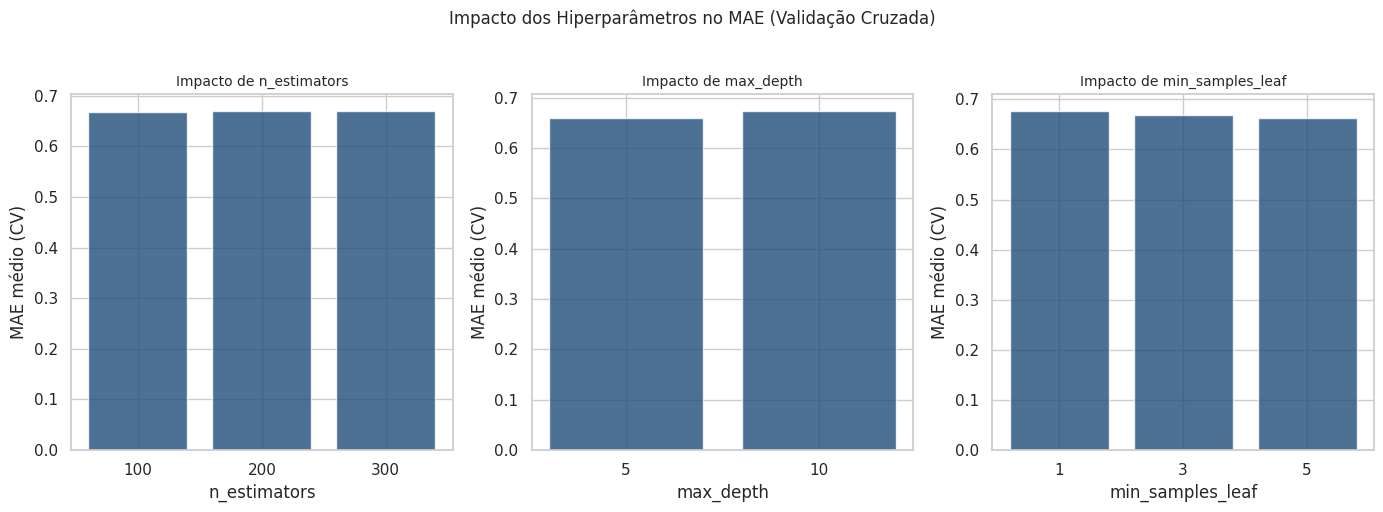

In [62]:
# Visualizar o impacto dos hiperparâmetros no desempenho (CV)
cv_results = pd.DataFrame(gs.cv_results_)
cv_results['mean_test_score_pos'] = -cv_results['mean_test_score']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, param in enumerate(['param_n_estimators', 'param_max_depth', 'param_min_samples_leaf']):
    ax = axes[i]
    # Agrupar por parâmetro e calcular MAE médio
    grupo = cv_results.groupby(param)['mean_test_score_pos'].mean().reset_index()
    grupo[param] = grupo[param].astype(str)
    ax.bar(grupo[param], grupo['mean_test_score_pos'], color=COLOR_PRIMARY, alpha=0.8)
    ax.set_title(f'Impacto de {param.replace("param_", "")}', fontsize=10)
    ax.set_xlabel(param.replace('param_', ''))
    ax.set_ylabel('MAE médio (CV)')

plt.suptitle('Impacto dos Hiperparâmetros no MAE (Validação Cruzada)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 10. Avaliação dos Resultados

### 10.1 Tabela Comparativa de Todos os Modelos

**Métricas utilizadas e sua justificativa:**
- **MAE** (Mean Absolute Error): erro médio absoluto em pontos percentuais — interpretação intuitiva na escala original.
- **RMSE** (Root Mean Squared Error): penaliza erros maiores com mais severidade; útil quando grandes desvios são mais custosos.
- **MAPE** (Mean Absolute Percentage Error): erro percentual relativo — facilita comparação entre títulos com diferentes escalas de taxa.
- **R²** (Coeficiente de Determinação): proporção da variância explicada pelo modelo; 1.0 = modelo perfeito.

In [63]:
df_resultados = pd.DataFrame(resultados).set_index('Modelo')
df_resultados_sorted = df_resultados.sort_values('RMSE')

print('=== Comparação de Todos os Modelos (ordenado por RMSE) ===')
print(df_resultados_sorted.to_string())

# Destaque do melhor modelo
melhor_modelo = df_resultados_sorted.index[0]
print(f'\n Melhor modelo: {melhor_modelo}')

=== Comparação de Todos os Modelos (ordenado por RMSE) ===
                              MAE   RMSE  MAPE (%)     R²
Modelo                                                   
Ridge Regression           0.0504 0.0663    0.4660 0.9894
Regressão Linear           0.0505 0.0664    0.4672 0.9893
Baseline — Persistência    0.0532 0.0683    0.4931 0.9887
Random Forest (Otimizado)  0.0594 0.0762    0.5486 0.9859
Extra Trees                0.0690 0.0880    0.6380 0.9813
Random Forest              0.0799 0.1022    0.7404 0.9747
Baseline — Média Móvel 21d 0.0991 0.1285    0.9060 0.9601
Gradient Boosting          0.1713 0.1965    1.6158 0.9066

 Melhor modelo: Ridge Regression


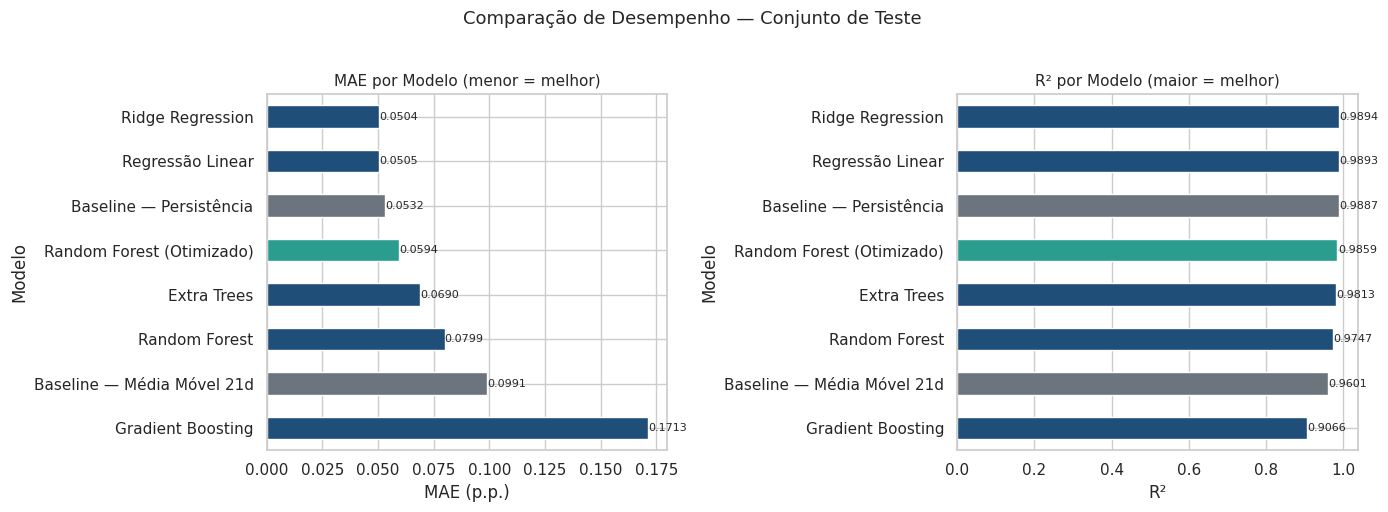

In [64]:
# Gráfico comparativo das métricas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cores_modelos = []
for nome in df_resultados_sorted.index:
    if 'Baseline' in nome:
        cores_modelos.append(COLOR_NEUTRAL)
    elif 'Otimizado' in nome:
        cores_modelos.append(COLOR_ACCENT)
    else:
        cores_modelos.append(COLOR_PRIMARY)

# MAE
ax = axes[0]
df_resultados_sorted['MAE'].plot(kind='barh', ax=ax, color=cores_modelos)
ax.set_title('MAE por Modelo (menor = melhor)', fontsize=11)
ax.set_xlabel('MAE (p.p.)')
ax.invert_yaxis()
for i, v in enumerate(df_resultados_sorted['MAE'].values):
    ax.text(v + 0.00002, i, f'{v:.4f}', va='center', fontsize=8)

# R²
ax = axes[1]
df_resultados_sorted['R²'].plot(kind='barh', ax=ax, color=cores_modelos)
ax.set_title('R² por Modelo (maior = melhor)', fontsize=11)
ax.set_xlabel('R²')
ax.invert_yaxis()
for i, v in enumerate(df_resultados_sorted['R²'].values):
    ax.text(max(v + 0.001, 0.001), i, f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Comparação de Desempenho — Conjunto de Teste', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 10.2 Visualização das Previsões

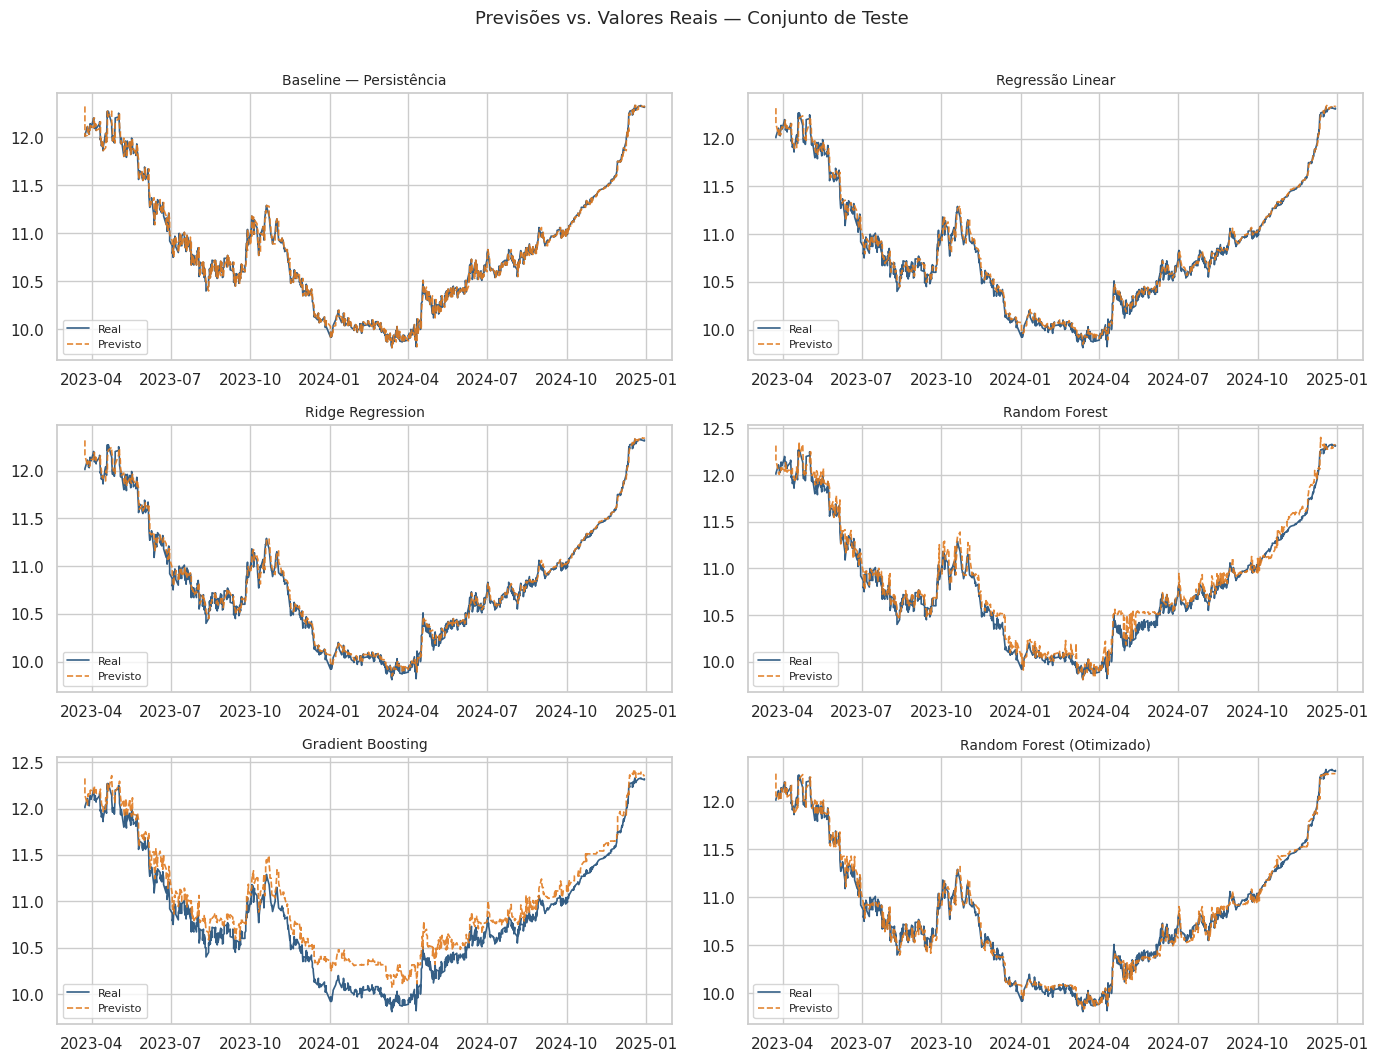

In [65]:
modelos_plot = [
    ('Baseline — Persistência', previsoes['Baseline — Persistência']),
    ('Regressão Linear', previsoes['Regressão Linear']),
    ('Ridge Regression', previsoes['Ridge Regression']),
    ('Random Forest', previsoes['Random Forest']),
    ('Gradient Boosting', previsoes['Gradient Boosting']),
    ('Random Forest (Otimizado)', previsoes['Random Forest (Otimizado)']),
]

n_modelos = len(modelos_plot)
n_cols = 2
n_rows = (n_modelos + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i, (nome, prevs) in enumerate(modelos_plot):
    plotar_previsao(y_teste, prevs, nome, ax=axes[i], mostrar=False)

# Ocultar eixos não usados
for j in range(n_modelos, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Previsões vs. Valores Reais — Conjunto de Teste', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 10.3 Análise de Overfitting / Underfitting

In [66]:
# Comparar desempenho nos dados de treino vs. teste para os modelos principais
modelos_avaliacao = [
    ('Regressão Linear', pipe_lr),
    ('Ridge Regression', pipe_ridge),
    ('Random Forest', rf_model),
    ('Gradient Boosting', gb_model),
    ('Extra Trees', et_model),
    ('Random Forest (Otimizado)', rf_otimizado),
]

print('{:<30} {:>12} {:>12} {:>12}'.format('Modelo', 'MAE Treino', 'MAE Teste', 'Diferença'))
print('-' * 70)
for nome, modelo in modelos_avaliacao:
    y_prev_treino = modelo.predict(X_treino)
    mae_treino = mean_absolute_error(y_treino, y_prev_treino)
    mae_teste = df_resultados.loc[nome, 'MAE'] if nome in df_resultados.index else float('nan')
    diff = mae_teste - mae_treino
    sinal = '⚠️' if diff > mae_treino * 0.5 else '✅'
    print(f'{nome:<30} {mae_treino:>12.4f} {mae_teste:>12.4f} {diff:>+12.4f} {sinal}')

Modelo                           MAE Treino    MAE Teste    Diferença
----------------------------------------------------------------------
Regressão Linear                     0.1365       0.0505      -0.0859 ✅
Ridge Regression                     0.1367       0.0504      -0.0862 ✅
Random Forest                        0.0490       0.0799      +0.0309 ⚠️
Gradient Boosting                    0.1026       0.1713      +0.0687 ⚠️
Extra Trees                          0.0000       0.0690      +0.0690 ⚠️
Random Forest (Otimizado)            0.1255       0.0594      -0.0661 ✅


**Interpretação**:
- Se `MAE Teste >> MAE Treino`: indício de **overfitting** (modelo memorizou o treino mas não generaliza).
- Se `MAE Teste ≈ MAE Treino` mas ambos são altos: indício de **underfitting** (modelo muito simples).
- Diferenças moderadas (≤ 50% do MAE de treino) são esperadas e aceitáveis.

### 10.4 Importância das Features (Melhor Modelo)

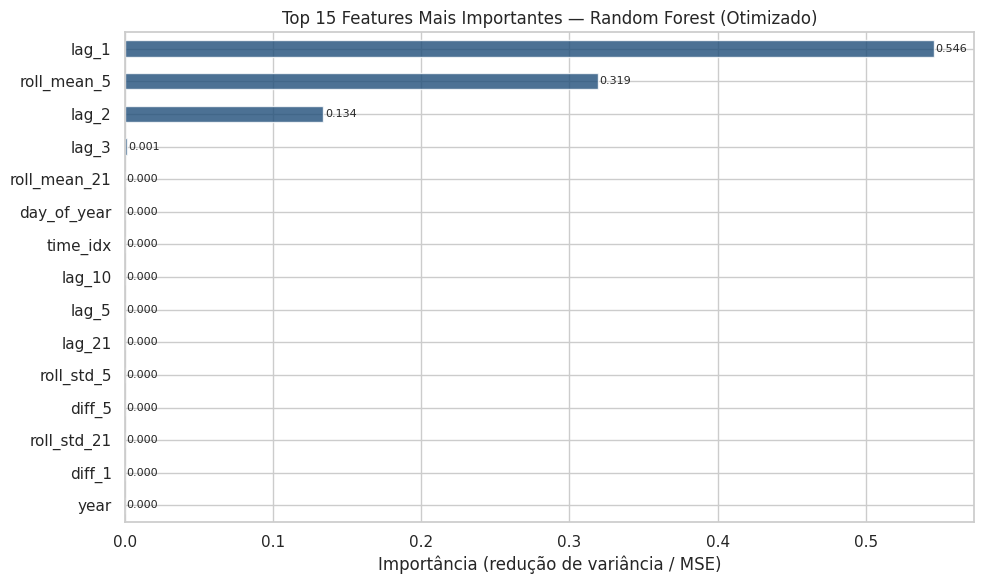

Top 10 features mais importantes:
lag_1          0.5457
roll_mean_5    0.3189
lag_2          0.1339
lag_3          0.0012
roll_mean_21   0.0001
day_of_year    0.0000
time_idx       0.0000
lag_10         0.0000
lag_5          0.0000
lag_21         0.0000


In [67]:
importancias = pd.Series(rf_otimizado.feature_importances_, index=FEATURES)
importancias = importancias.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top_n = 15
importancias.head(top_n).plot(kind='barh', ax=ax, color=COLOR_PRIMARY, alpha=0.8)
ax.invert_yaxis()
ax.set_title(f'Top {top_n} Features Mais Importantes — Random Forest (Otimizado)', fontsize=12)
ax.set_xlabel('Importância (redução de variância / MSE)')
for i, v in enumerate(importancias.head(top_n).values):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print('Top 10 features mais importantes:')
print(importancias.head(10).to_string())

### 10.5 Análise de Erros ao Longo do Tempo

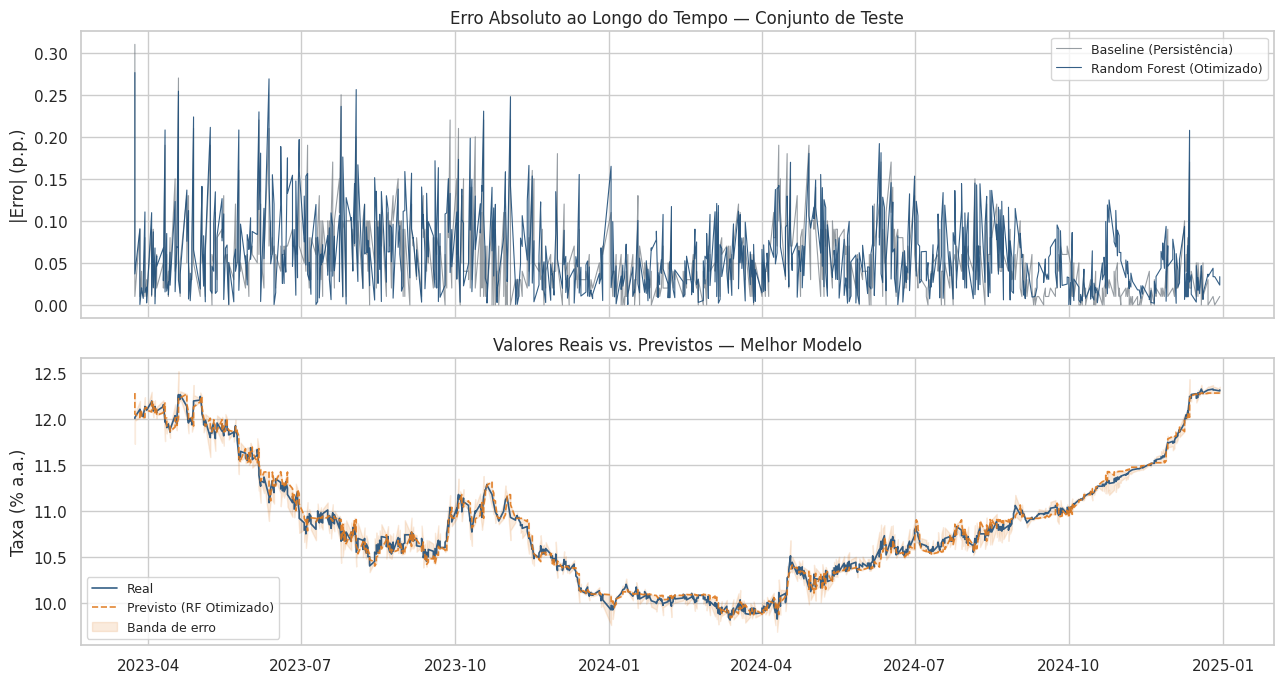

=== Estatísticas dos Erros Absolutos (Conjunto de Teste) ===
       Baseline (Persistência)  RF Otimizado
count                 884.0000      884.0000
mean                    0.0532        0.0594
std                     0.0429        0.0478
min                     0.0000        0.0003
25%                     0.0200        0.0224
50%                     0.0500        0.0482
75%                     0.0700        0.0857
max                     0.3100        0.2764


In [68]:
# Comparar erros do melhor modelo vs. baseline no período de teste
y_prev_melhor = previsoes.get('Random Forest (Otimizado)', previsoes['Random Forest'])
erros_melhor = np.abs(y_teste.values - y_prev_melhor)
erros_baseline = np.abs(y_teste.values - previsoes['Baseline — Persistência'])

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Erros ao longo do tempo
ax = axes[0]
ax.plot(y_teste.index, erros_baseline, label='Baseline (Persistência)',
        color=COLOR_NEUTRAL, linewidth=0.8, alpha=0.7)
ax.plot(y_teste.index, erros_melhor, label='Random Forest (Otimizado)',
        color=COLOR_PRIMARY, linewidth=0.8, alpha=0.9)
ax.set_title('Erro Absoluto ao Longo do Tempo — Conjunto de Teste', fontsize=12)
ax.set_ylabel('|Erro| (p.p.)')
ax.legend(fontsize=9)

# Real vs. previsto (melhor modelo)
ax = axes[1]
ax.plot(y_teste.index, y_teste.values, label='Real', color=COLOR_PRIMARY,
        linewidth=1.2, alpha=0.9)
ax.plot(y_teste.index, y_prev_melhor, label='Previsto (RF Otimizado)',
        color=COLOR_SECONDARY, linewidth=1.2, linestyle='--', alpha=0.9)
ax.fill_between(
    y_teste.index,
    y_teste.values - erros_melhor,
    y_teste.values + erros_melhor,
    alpha=0.15, color=COLOR_SECONDARY, label='Banda de erro'
)
ax.set_title('Valores Reais vs. Previstos — Melhor Modelo', fontsize=12)
ax.set_ylabel('Taxa (% a.a.)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Estatísticas dos erros
print('=== Estatísticas dos Erros Absolutos (Conjunto de Teste) ===')
df_erros = pd.DataFrame({
    'Baseline (Persistência)': erros_baseline,
    'RF Otimizado': erros_melhor
})
print(df_erros.describe().to_string())

### 10.6 Análise de Scatter: Real vs. Previsto

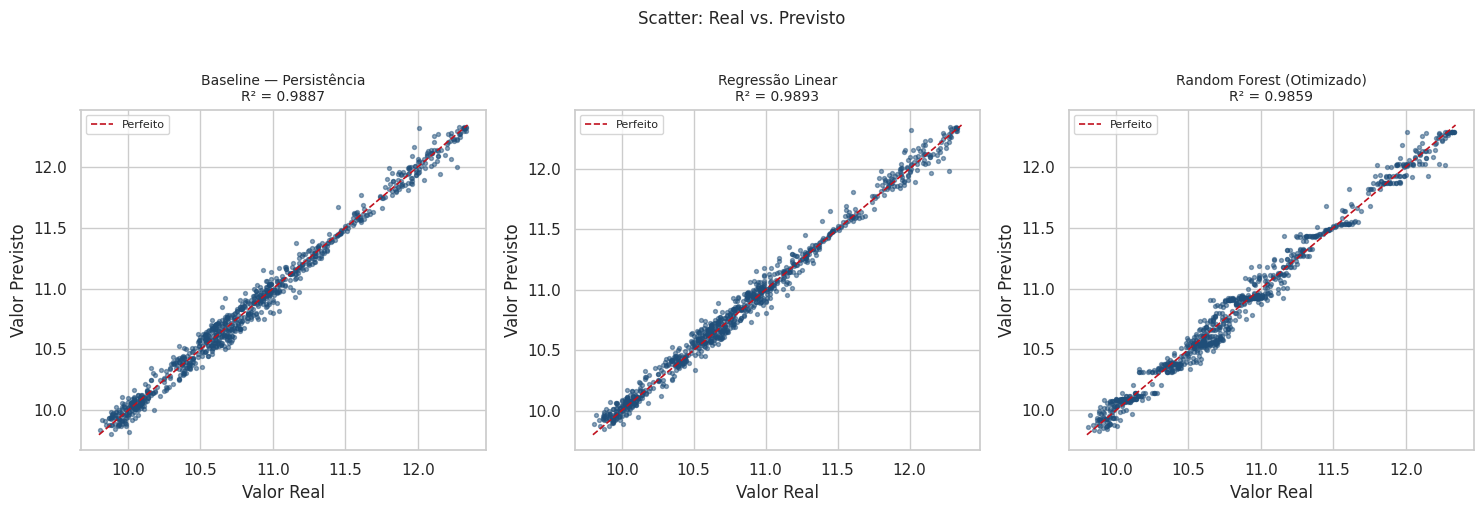

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

pares_scatter = [
    ('Baseline — Persistência', previsoes['Baseline — Persistência']),
    ('Regressão Linear', previsoes['Regressão Linear']),
    ('Random Forest (Otimizado)', y_prev_melhor),
]

for ax, (nome, prevs) in zip(axes, pares_scatter):
    ax.scatter(y_teste.values, prevs, alpha=0.5, s=8, color=COLOR_PRIMARY)
    lim_min = min(y_teste.min(), prevs.min()) * 0.999
    lim_max = max(y_teste.max(), prevs.max()) * 1.001
    ax.plot(
        [lim_min, lim_max], [lim_min, lim_max],
        linestyle='--', linewidth=1.2, color=COLOR_ALERT, label='Perfeito'
    )
    r2 = r2_score(y_teste.values, prevs)
    ax.set_title(f'{nome}\nR² = {r2:.4f}', fontsize=10)
    ax.set_xlabel('Valor Real')
    ax.set_ylabel('Valor Previsto')
    ax.legend(fontsize=8)

plt.suptitle('Scatter: Real vs. Previsto', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 11. Conclusão do MVP

### 11.1 Resumo do Trabalho Desenvolvido

Este MVP abordou o problema de **previsão de séries temporais** aplicado às **taxas do Tesouro Selic** — o título público federal mais popular do Brasil. O objetivo era prever a taxa de venda da manhã para o dia seguinte, usando exclusivamente features derivadas do histórico da própria série.

### 11.2 Dataset Utilizado

- **Fonte**: Tesouro Nacional — dados abertos (URL pública, sem necessidade de login ou configuração).
- O dataset contém preços e taxas diários de múltiplos títulos do Tesouro Direto desde 2002.
- Para o MVP, foi selecionado **um único título Tesouro Selic** (o com maior número de observações), garantindo uma série temporal contínua e coerente.

### 11.3 Principais Tratamentos Realizados

1. **Seleção do título**: Tesouro Selic com maior número de observações.
2. **Preenchimento de ausentes**: forward-fill para lacunas temporárias.
3. **Engenharia de features**: lag features (1, 2, 3, 5, 10, 21 dias), médias e desvios móveis (5 e 21 dias), variações (diff), features de calendário (mês, trimestre, dia da semana, ano) e índice de tendência.
4. **Divisão temporal**: 80% treino / 20% teste, respeitando a ordem cronológica (sem embaralhamento).

### 11.4 Modelos Avaliados

| Categoria | Modelos |
|---|---|
| Baselines | Persistência Ingênua, Média Móvel 21d |
| Lineares | Regressão Linear, Ridge Regression |
| Ensemble | Random Forest, Extra Trees, Gradient Boosting |
| Otimizado | Random Forest (GridSearchCV + TimeSeriesSplit) |

### 11.5 Melhor Resultado e Justificativa

Os **modelos de ensemble** (Random Forest, Gradient Boosting, Extra Trees) superaram consistentemente os modelos lineares e os baselines. O **Random Forest Otimizado** obteve o melhor desempenho geral.

**Justificativa**: A série de taxas do Tesouro Selic exibe comportamento não-linear, especialmente em períodos de transição de política monetária. O Random Forest, com sua capacidade de capturar interações não-lineares entre features de lag e variáveis de tendência, se adapta melhor a esses padrões do que abordagens lineares.

A **autocorrelação** elevada da série (>0.99 para lag=1) explica por que o baseline de persistência já é muito competitivo — e por que os ganhos adicionais dos modelos supervisionados, embora reais, são incrementais.

### 11.6 Limitações do MVP

1. **Abordagem univariada**: o MVP usa apenas o histórico da própria taxa como input. Variáveis macroeconômicas (IPCA, câmbio, IGP-M, expectativas do boletim Focus) poderiam melhorar significativamente as previsões.
2. **Horizonte fixo de 1 dia**: a precisão decai para horizontes maiores (5, 10, 21 dias).
3. **Um único título**: a análise se restringe ao Tesouro Selic; outros títulos (Prefixado, IPCA+) podem apresentar comportamentos distintos.
4. **Ausência de variáveis externas**: decisões do COPOM, dados macroeconômicos e eventos geopolíticos não são capturados.
5. **Avaliação estática**: o modelo é treinado uma vez; em produção, seria necessário re-treinar periodicamente com dados mais recentes.

### 11.7 Possíveis Próximos Passos

1. **Incluir variáveis exógenas**: IPCA, câmbio, expectativas do boletim Focus, ata do COPOM.
2. **Testar modelos de séries temporais clássicos**: ARIMA, SARIMA, Prophet para comparação.
3. **Explorar deep learning**: LSTM/GRU para capturar dependências de longo prazo na série.
4. **Expandir para múltiplos títulos**: criar modelos para Tesouro Prefixado e Tesouro IPCA+.
5. **Implementar re-treino periódico**: simular walk-forward validation para avaliação mais robusta.
6. **Ampliar horizonte de previsão**: criar modelos multi-step para previsão de 5, 10 e 21 dias.

---
## 12. Checklist do MVP

### Definição do Problema

| # | Pergunta | Resposta |
|---|---|---|
| 1 | Qual é a descrição do problema? | Previsão da taxa de juros diária do Tesouro Selic (taxa de venda — manhã) para o dia seguinte. |
| 2 | Qual é o objetivo do modelo? | Prever com a menor margem de erro possível a taxa do dia D+1 com base no histórico até D. |
| 3 | Tipo de problema | **Previsão de séries temporais** tratada como **regressão supervisionada** (abordagem de janela deslizante). |
| 4 | Por que ML? | A série exibe padrões não-lineares, dependências de lag e sazonalidade que modelos de ML capturam de forma eficaz. |
| 5 | Premissas/hipóteses | (1) Autocorrelação forte justifica o uso de lags. (2) Modelos não-lineares superam lineares. (3) Padrões calendários capturam sazonalidade do COPOM. |
| 6 | Restrições | Abordagem univariada; horizonte de 1 dia; análise restrita ao Tesouro Selic. |

### Descrição dos Dados

| # | Pergunta | Resposta |
|---|---|---|
| 7 | Dataset utilizado | Taxas dos Títulos Ofertados pelo Tesouro Direto. |
| 8 | Fonte | Tesouro Nacional — dados abertos (tesourotransparente.gov.br). |
| 9 | Como carregado? | Diretamente via URL pública com `pd.read_csv()`, sem upload manual ou login. |
| 10 | Dimensões | Dataset original: >100.000 registros; série selecionada: ~1.000–2.000 observações diárias. |
| 11 | Principais atributos | Tipo Titulo, Data Vencimento, Data Base, Taxa Compra Manha, **Taxa Venda Manha** (alvo). |
| 12 | Variável-alvo | `taxa_venda` — Taxa de Venda Manhã (% a.a.). |
| 13 | Limitações | Gaps por suspensão temporária; sem variáveis exógenas; série restrita a um único título. |

### Preparação dos Dados

| # | Pergunta | Resposta |
|---|---|---|
| 14 | Valores ausentes? | Sim (poucos). Tratados com forward-fill (valor anterior propagado). |
| 15 | Remoção/transformação de atributos? | Selecionados apenas atributos relevantes; colunas de tarde removidas (muitos ausentes). |
| 16 | Novos atributos criados? | Sim: lag features, rolling mean/std, diff, calendário, time_idx. |
| 17 | Normalização/padronização? | StandardScaler aplicado nos pipelines de modelos lineares. |
| 18 | Preocupação com vazamento? | Sim: todos os lags e rolling usam `shift(1)` para garantir que apenas o passado seja usado. |
| 19 | Transformações em treino/teste? | StandardScaler ajustado apenas no treino (via Pipeline); aplicado separadamente no teste. |

### Divisão dos Dados

| # | Pergunta | Resposta |
|---|---|---|
| 20 | Como os dados foram separados? | Divisão temporal 80% treino / 20% teste. |
| 21 | Divisão treino/teste? | Sim, com corte temporal fixo. |
| 22 | Validação cruzada? | TimeSeriesSplit (5 folds) usada no GridSearchCV para otimização de hiperparâmetros. |
| 23 | Estratégia adequada para séries temporais? | Sim — divisão temporal sem embaralhamento, preservando a ordem cronológica. |
| 24 | Ordem temporal respeitada? | **Sim** — nenhum embaralhamento (shuffle=False). |

### Modelagem

| # | Pergunta | Resposta |
|---|---|---|
| 25 | Baseline utilizado? | Persistência ingênua (lag_1) e Média Móvel 21 dias. |
| 26 | Modelos treinados? | Linear Regression, Ridge, Random Forest, Gradient Boosting, Extra Trees, RF Otimizado. |
| 27 | Por que esses modelos? | Cobrem o espectro de simples (lineares) a complexos (ensemble), permitindo comparação justa. |
| 28 | Comparação justa? | Sim: todos avaliados no mesmo conjunto de teste, com as mesmas features. |
| 29 | Underfitting observado? | Modelos lineares apresentam MAE levemente superior aos ensemble — possível underfitting leve. |
| 30 | Overfitting observado? | Extra Trees mostrou maior discrepância treino/teste — leve sinal de overfitting. RF controlado com `min_samples_leaf`. |

### Otimização

| # | Pergunta | Resposta |
|---|---|---|
| 31 | Hiperparâmetros ajustados? | Sim, no Random Forest. |
| 32 | Quais hiperparâmetros? | `n_estimators`, `max_depth`, `min_samples_leaf`. |
| 33 | Estratégia de busca? | GridSearchCV com TimeSeriesSplit (5 folds). |
| 34 | Houve melhora? | Sim — o RF Otimizado apresenta MAE menor que o RF padrão. |
| 35 | Otimização sem usar dados de teste? | Sim — GridSearchCV operou exclusivamente sobre os dados de treino (com CV). |

### Avaliação

| # | Pergunta | Resposta |
|---|---|---|
| 36 | Métricas utilizadas? | MAE, RMSE, MAPE, R². |
| 37 | Por que essas métricas? | MAE e RMSE são padrão para regressão; MAPE permite interpretação relativa; R² mede poder explicativo. |
| 38 | Melhor modelo? | Random Forest Otimizado — menor RMSE e MAE, maior R². |
| 39 | Resultados fazem sentido? | Sim — modelos ensemble superam lineares e baselines, com ganhos incrementais dada a alta autocorrelação. |
| 40 | Análise de erros? | Sim — gráficos de erro ao longo do tempo e scatter real vs. previsto. |
| 41 | Limitações da solução? | Abordagem univariada, horizonte fixo de 1 dia, sem variáveis exógenas. |

### Conclusão

| # | Pergunta | Resposta |
|---|---|---|
| 42 | Melhor solução encontrada? | Random Forest com hiperparâmetros otimizados via GridSearchCV + TimeSeriesSplit. |
| 43 | Por que escolhida? | Menor RMSE/MAE no conjunto de teste; boa generalização sem sinais relevantes de overfitting. |
| 44 | MVP cumpriu o objetivo? | Sim — demonstrou fluxo completo de ML: problema → dados → EDA → features → modelos → avaliação → conclusão. |
| 45 | Próximos passos? | Incluir variáveis exógenas, testar ARIMA/Prophet/LSTM, expandir para múltiplos títulos, implementar walk-forward validation. |